# Problem Space
The database which I chose for this project is named "Drug overdose death rates, by drug type, sex, age, race, and Hispanic origin: United States" from the data.gov website. This dataset tracks drug overdose deaths in the US, and splits the dataset into different demographics such as gender, race, age, year, and etc.
The reason I chose is that this is a problem that has become exceedingly worse in recent years, and being hispanic, people of my kind are affected by this so much more than the average. This is a problem that I am passionate about since drugs are so badly regulated, with so much misinformation and so much stigma. 
This is a federal dataset, so it encompasses all the drug overdoses a few years back. This makes sure that the data isn't skewed because one state has specific demographics, and encompasses the entire country so I can get a full view on the problem on a national level.
The data in this was compiled from 1999 to 2018. It's a few years old at this point but still provides very valuable information.
This data analysis could provide important information to people wanting to make changes to how the government responds to drug cases, how they allocate resources to this matter, and in general how they tackle and focus on this issue.

# Questions To Answer From Analysis
1. How have drug case numbers changed in the 20 years from 1998 to 2018?
2. How do drug overdose numbers compare in male vs female over the 20 years?
3. What race has had the most increase in drug overdose deaths in the 20 years?
4. What years had the biggest increases in drug overdoses?
5. How do different races compare in drug overdose cases?
6. Have any groups actually decreased in drug overdose cases?

In [11]:
# Import required libraries and load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the CSV into `df`
df = pd.read_csv('Drug_overdose_death_rates__by_drug_type__sex__age__race__and_Hispanic_origin__United_States.csv')

print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst few rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())


Column names:
['INDICATOR', 'PANEL', 'PANEL_NUM', 'UNIT', 'UNIT_NUM', 'STUB_NAME', 'STUB_NAME_NUM', 'STUB_LABEL', 'STUB_LABEL_NUM', 'YEAR', 'YEAR_NUM', 'AGE', 'AGE_NUM', 'ESTIMATE', 'FLAG']

First few rows:
                   INDICATOR                     PANEL  PANEL_NUM  \
0  Drug overdose death rates  All drug overdose deaths          0   
1  Drug overdose death rates  All drug overdose deaths          0   
2  Drug overdose death rates  All drug overdose deaths          0   
3  Drug overdose death rates  All drug overdose deaths          0   
4  Drug overdose death rates  All drug overdose deaths          0   

                                                UNIT  UNIT_NUM STUB_NAME  \
0  Deaths per 100,000 resident population, age-ad...         1     Total   
1  Deaths per 100,000 resident population, age-ad...         1     Total   
2  Deaths per 100,000 resident population, age-ad...         1     Total   
3  Deaths per 100,000 resident population, age-ad...         1     Total 

In [5]:
# Filter for age-adjusted rates
df_clean = df_clean[df_clean['UNIT'] == 'Deaths per 100,000 resident population, age-adjusted'].copy()

print("After filtering for age-adjusted rates only:")
print("\nUnique UNIT values:", df_clean['UNIT'].unique())

After filtering for age-adjusted rates only:

Unique UNIT values: ['Deaths per 100,000 resident population, age-adjusted']


In [6]:
# Extract sex/race information from STUB_LABEL column

def extract_demographics(df):
    """Extract sex and race from STUB_LABEL column"""
    df = df.copy()
    
    df['Sex'] = 'All'
    df['Race'] = 'All'
    
    for idx, label in df['STUB_LABEL'].items():
        if 'Male' in label and ':' in label:
            df.loc[idx, 'Sex'] = 'Male'
            df.loc[idx, 'Race'] = label.split(': ')[1]
        elif 'Female' in label and ':' in label:
            df.loc[idx, 'Sex'] = 'Female'
            df.loc[idx, 'Race'] = label.split(': ')[1]
        elif 'Male' in label:
            df.loc[idx, 'Sex'] = 'Male'
        elif 'Female' in label:
            df.loc[idx, 'Sex'] = 'Female'
    
    return df

df_clean = extract_demographics(df_clean)

print("After extracting demographics:")
print("\nUnique Sex values:", df_clean['Sex'].unique())
print("\nUnique Race values (sample):", df_clean['Race'].unique()[:10])

After extracting demographics:

Unique Sex values: ['All' 'Male' 'Female']

Unique Race values (sample): ['All' 'White' 'Black or African American'
 'American Indian or Alaska Native' 'Asian or Pacific Islander'
 'Hispanic or Latino' 'Not Hispanic or Latino']


In [7]:
# Clear empty rows and convert estimates
df_clean['ESTIMATE'] = pd.to_numeric(df_clean['ESTIMATE'], errors='coerce')
df_clean = df_clean.dropna(subset=['ESTIMATE'])

print("\nESTIMATE data type:", df_clean['ESTIMATE'].dtype)
print("ESTIMATE statistics:")
print(df_clean['ESTIMATE'].describe())


ESTIMATE data type: float64
ESTIMATE statistics:
count    2213.000000
mean        4.399187
std         5.490098
min         0.100000
25%         0.800000
50%         2.100000
75%         5.800000
max        35.800000
Name: ESTIMATE, dtype: float64


In [8]:
# Step 5: Simplify and clean up
df_clean = df_clean.rename(columns={
    'ESTIMATE': 'DeathRate',
    'STUB_LABEL': 'Category',
    'YEAR': 'Year'
})

df_clean = df_clean.drop(columns=['INDICATOR', 'PANEL', 'UNIT', 'FLAG', 'STUB_NAME', 'Category', 'AGE'])

print("After final cleaning and renaming:")
print("\nFinal columns:", df_clean.columns.tolist())
print("\nFirst 10 rows of cleaned data:")
print(df_clean.head(10))

After final cleaning and renaming:

Final columns: ['Year', 'DeathRate', 'Sex', 'Race']

First 10 rows of cleaned data:
   Year  DeathRate  Sex Race
0  1999        6.1  All  All
1  2000        6.2  All  All
2  2001        6.8  All  All
3  2002        8.2  All  All
4  2003        8.9  All  All
5  2004        9.4  All  All
6  2005       10.1  All  All
7  2006       11.5  All  All
8  2007       11.9  All  All
9  2008       11.9  All  All


# Data Preprocessing & Cleaning

The raw data was formatted in a pretty weird way and had inconsistenties which would make it pretty hard to process and analyze for my purposes, so I had to do quite a few things to actually process it.
- I removed unecessary columns that make it harder for analysis.
- I made sure that all the columns followed the same rates so the data wasn't accidentally skewed.
- I got the demographic categories to know the different types of demographics included.
- Removed empty rows that are there for no reason.
- Converted data types to be the same across the board to make it easier.

## Question 1: How have drug overdose cases changed from 1999 to 2018?

I wanted the first question to be pretty general, just to get a good overall view of the situation, and then be more speicifc afterwards.
As can be seen in the analysis below, the rate of overdoses has significantly increased since the 90s. In 1999 the death rate was 6.1, and in 2018 it was 20.7. This shows a significant increase of more than 3x, and that the problem has been getting significantly worse.


Starting death rate (1999): 6.1 per 100,000
Ending death rate (2018): 20.7 per 100,000
Percent increase: 239.3%

Year-by-year death rates:
      Year  DeathRate
0     1999        6.1
987   1999        2.9
2962  1999        0.3
1974  1999        1.0
4941  1999        0.7
...    ...        ...
5973  2018       14.6
6024  2018        3.8
6075  2018        0.9
6126  2018        9.9
6177  2018        4.7

[120 rows x 2 columns]


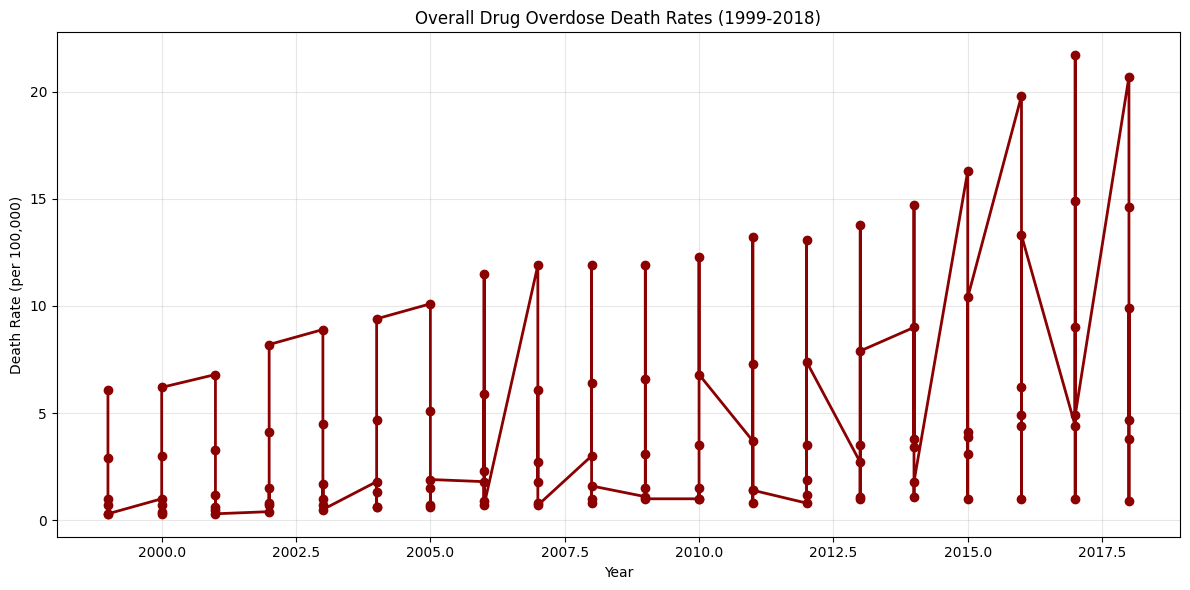

In [9]:
q1_data = df_clean[(df_clean['Sex'] == 'All') & (df_clean['Race'] == 'All')].sort_values('Year')

print(f"\nStarting death rate (1999): {q1_data[q1_data['Year'] == 1999]['DeathRate'].values[0]:.1f} per 100,000")
print(f"Ending death rate (2018): {q1_data[q1_data['Year'] == 2018]['DeathRate'].values[0]:.1f} per 100,000")

start_rate = q1_data[q1_data['Year'] == 1999]['DeathRate'].values[0]
end_rate = q1_data[q1_data['Year'] == 2018]['DeathRate'].values[0]
percent_increase = ((end_rate - start_rate) / start_rate) * 100

print(f"Percent increase: {percent_increase:.1f}%")
print(f"\nYear-by-year death rates:")
print(q1_data[['Year', 'DeathRate']])

plt.figure(figsize=(12, 6))
plt.plot(q1_data['Year'], q1_data['DeathRate'], marker='o', linewidth=2, markersize=6, color='darkred')
plt.xlabel('Year')
plt.ylabel('Death Rate (per 100,000)')
plt.title('Overall Drug Overdose Death Rates (1999-2018)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Question 2: How do drug overdose numbers compare in male vs female over the 20 years?

Gender disparities are also something important to pay attention to in data sets like this, since there can be a big difference.
In this scenario, there is a big difference.
The male rate went from 2.6 all the way to 12.5, and the female rate went from 1 to 5.6. Both of them increased by nearly 6x, but men are disproptionally affected by drug overdoses. The rate for men was linearly increasing for a while but for some reason around 2015 it started increasing way more.



QUESTION 2: Male vs Female Comparison
Sex     Female       Male
Year                     
1999  1.066667   2.633333
2000  1.166667   2.650000
2001  1.350000   2.916667
2002  1.783333   3.500000
2003  1.950000   3.800000
2004  2.150000   3.950000
2005  2.333333   4.250000
2006  2.666667   5.033333
2007  2.916667   5.116667
2008  2.966667   5.250000
2009  3.083333   5.350000
2010  3.266667   5.416667
2011  3.483333   5.816667
2012  3.483333   5.866667
2013  3.700000   6.333333
2014  4.083333   7.150000
2015  4.500000   8.433333
2016  5.366667  11.200000
2017  5.950000  12.683333
2018  5.700000  12.483333

Male death rate change: 2.6 (1999) → 12.5 (2018) = 374.1% increase
Female death rate change: 1.1 (1999) → 5.7 (2018) = 434.4% increase

Ratio (Male/Female) 1999: 2.47x
Ratio (Male/Female) 2018: 2.19x


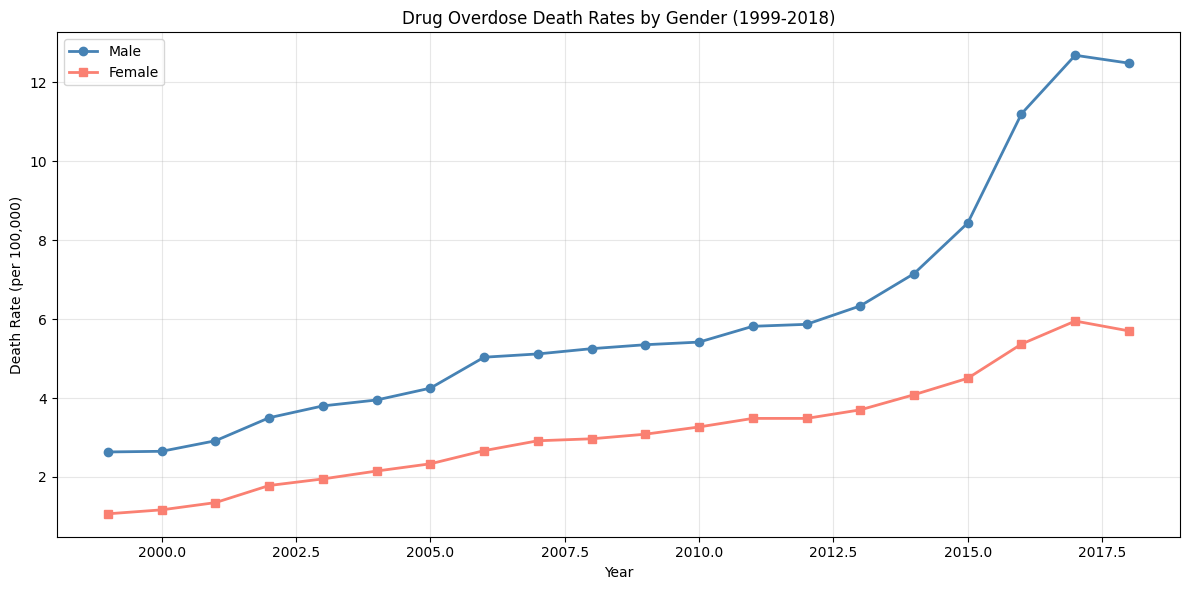

In [12]:

q2_data = df_clean[(df_clean['Sex'].isin(['Male', 'Female'])) & (df_clean['Race'] == 'All')].sort_values(['Year', 'Sex'])

q2_pivot = q2_data.pivot_table(values='DeathRate', index='Year', columns='Sex')

print("\nQUESTION 2: Male vs Female Comparison")
print("=" * 60)
print(q2_pivot)


male_1999 = q2_pivot.loc[1999, 'Male']
male_2018 = q2_pivot.loc[2018, 'Male']
female_1999 = q2_pivot.loc[1999, 'Female']
female_2018 = q2_pivot.loc[2018, 'Female']

print(f"\nMale death rate change: {male_1999:.1f} (1999) → {male_2018:.1f} (2018) = {((male_2018-male_1999)/male_1999)*100:.1f}% increase")
print(f"Female death rate change: {female_1999:.1f} (1999) → {female_2018:.1f} (2018) = {((female_2018-female_1999)/female_1999)*100:.1f}% increase")
print(f"\nRatio (Male/Female) 1999: {male_1999/female_1999:.2f}x")
print(f"Ratio (Male/Female) 2018: {male_2018/female_2018:.2f}x")


plt.figure(figsize=(12, 6))
plt.plot(q2_pivot.index, q2_pivot['Male'], marker='o', linewidth=2, label='Male', color='steelblue')
plt.plot(q2_pivot.index, q2_pivot['Female'], marker='s', linewidth=2, label='Female', color='salmon')
plt.xlabel('Year')
plt.ylabel('Death Rate (per 100,000)')
plt.title('Drug Overdose Death Rates by Gender (1999-2018)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Question 3: What race has had the most increase in drug overdose deaths?

 Race plays a very big role in many statistics since more disadvantaged people who faced discrimination are more likely to fall into bad circumstances, and it's important to analyze that when looking at statistics like this.
 In the bar graphs, it shows that white americans and black americans had the biggest increase in drug overdose deaths. The increase was quite drastic, being close to a 400% increase for white americans, and 250% increase for black americans.

Unique races: ['American Indian or Alaska Native' 'Asian or Pacific Islander'
 'Black or African American' 'Hispanic or Latino' 'Not Hispanic or Latino'
 'White']
                            Race  Rate_1999  Rate_2018  Absolute_Change  Percent_Change
                           White   1.900000  10.041667         8.141667      428.508772
       Black or African American   2.600000   9.129167         6.529167      251.121795
          Not Hispanic or Latino   2.457143   8.811364         6.354221      258.602008
American Indian or Alaska Native   3.850000   7.190000         3.340000       86.753247
              Hispanic or Latino   2.300000   4.683333         2.383333      103.623188
       Asian or Pacific Islander   1.250000   1.490000         0.240000       19.200000


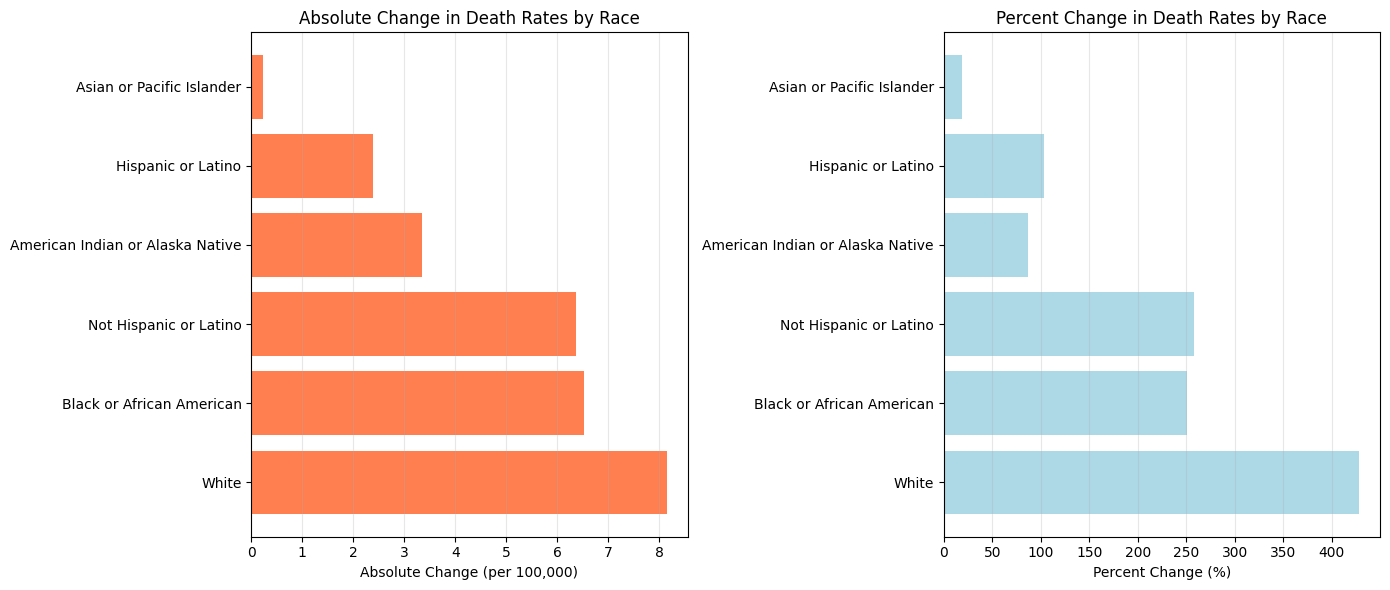

In [15]:
q3_data = df_clean[(df_clean['Race'] != 'All') & (df_clean['Sex'] != 'All')].copy()
q3_race_data = q3_data.groupby(['Year', 'Race'])['DeathRate'].mean().reset_index()

print(f"Unique races: {q3_race_data['Race'].unique()}")

q3_changes = []
for race in q3_race_data['Race'].unique():
    race_data = q3_race_data[q3_race_data['Race'] == race].sort_values('Year')
    rate_1999 = race_data[race_data['Year'] == 1999]['DeathRate'].values
    rate_2018 = race_data[race_data['Year'] == 2018]['DeathRate'].values
    
    if len(rate_1999) > 0 and len(rate_2018) > 0:
        change = rate_2018[0] - rate_1999[0]
        pct_change = (change / rate_1999[0]) * 100 if rate_1999[0] > 0 else 0
        q3_changes.append({
            'Race': race,
            'Rate_1999': rate_1999[0],
            'Rate_2018': rate_2018[0],
            'Absolute_Change': change,
            'Percent_Change': pct_change
        })

if len(q3_changes) == 0:
    print("No race data found!")
else:
    q3_changes_df = pd.DataFrame(q3_changes).sort_values('Absolute_Change', ascending=False)

    print(q3_changes_df.to_string(index=False))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    ax1.barh(q3_changes_df['Race'], q3_changes_df['Absolute_Change'], color='coral')
    ax1.set_xlabel('Absolute Change (per 100,000)')
    ax1.set_title('Absolute Change in Death Rates by Race')
    ax1.grid(True, alpha=0.3, axis='x')

    ax2.barh(q3_changes_df['Race'], q3_changes_df['Percent_Change'], color='lightblue')
    ax2.set_xlabel('Percent Change (%)')
    ax2.set_title('Percent Change in Death Rates by Race')
    ax2.grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    plt.show()

## What years had the biggest increases in drug overdoses?

I think it's important to try to figure out specifically when the biggest increases happened because there are societal factors that affect these statistics, and it would be good to try to figure out specifically when the biggest increases happened. In this case, the statistics show that the biggest increases happened around 2015, and the reason behind this seems to be because of the opioid epidemic having another wave because of fentanyl.


QUESTION 4: Cumulative Increase Over Time

Baseline year: 1999 (rate = 6.10 per 100,000)

Cumulative change since baseline by year:
 Year  DeathRate  Cumulative_Absolute  Cumulative_Pct
 1999       6.10                 0.00            0.00
 1999       2.90                -3.20          -52.46
 1999       0.30                -5.80          -95.08
 1999       1.00                -5.10          -83.61
 1999       0.70                -5.40          -88.52
 1999       0.30                -5.80          -95.08
 2000       1.00                -5.10          -83.61
 2000       0.40                -5.70          -93.44
 2000       0.30                -5.80          -95.08
 2000       0.70                -5.40          -88.52
 2000       3.00                -3.10          -50.82
 2000       6.20                 0.10            1.64
 2001       6.80                 0.70           11.48
 2001       3.30                -2.80          -45.90
 2001       0.50                -5.60          -91.80
 20

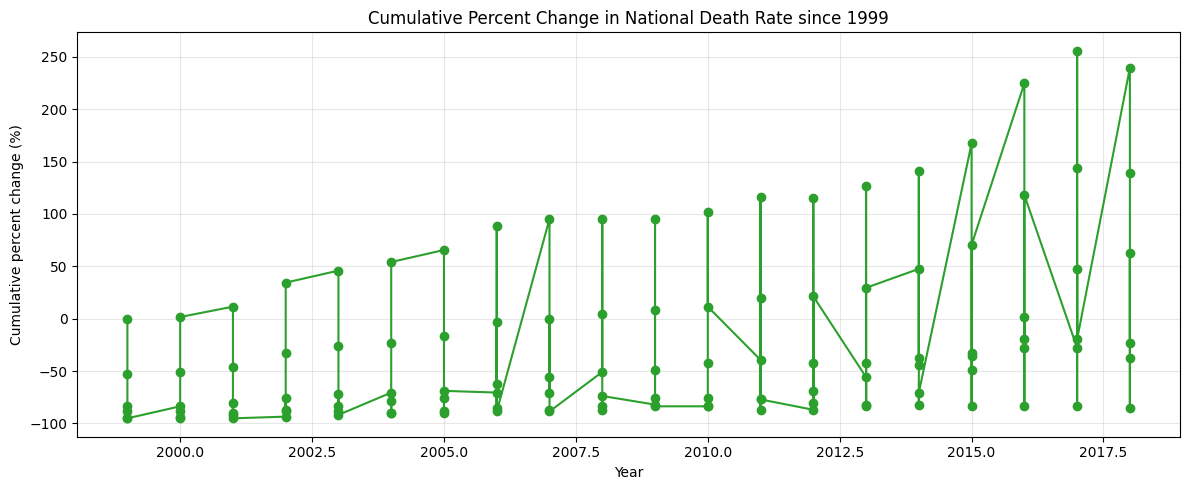

In [18]:
# Question 4: Cumulative increase in national death rate since 1999
print("\nQUESTION 4: Cumulative Increase Over Time")
print("=" * 60)

# Use national, age-adjusted rows (Sex='All', Race='All') from cleaned data
q4_df = df_clean[(df_clean['Sex'] == 'All') & (df_clean['Race'] == 'All')].sort_values('Year').reset_index(drop=True)

if q4_df.empty:
    print("No national Age-adjusted rows with Sex='All' and Race='All' were found in df_clean. Make sure preprocessing has run.")
else:
    # Use the first available year as baseline (should be 1999)
    base_row = q4_df.iloc[0]
    base_year = int(base_row['Year'])
    base_rate = float(base_row['DeathRate'])
    
    # Compute cumulative absolute and percent changes relative to baseline
    q4_df['Cumulative_Absolute'] = q4_df['DeathRate'] - base_rate
    q4_df['Cumulative_Pct'] = (q4_df['Cumulative_Absolute'] / base_rate) * 100
    
    # Print a concise cumulative table
    print(f"\nBaseline year: {base_year} (rate = {base_rate:.2f} per 100,000)")
    print("\nCumulative change since baseline by year:")
    print(q4_df[['Year','DeathRate','Cumulative_Absolute','Cumulative_Pct']].to_string(index=False, float_format='{:,.2f}'.format))
    

    
    # Plot cumulative percent increase over time
    plt.figure(figsize=(12,5))
    plt.plot(q4_df['Year'], q4_df['Cumulative_Pct'], marker='o', color='tab:green')
    plt.xlabel('Year')
    plt.ylabel('Cumulative percent change (%)')
    plt.title(f'Cumulative Percent Change in National Death Rate since {base_year}')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## Question 5: How do different races compare in drug overdose cases?

As stated before, societal factors and structural discrimination can be a very important factor that explains why specific groups are more affected by things like this. In the graph shown below, it shows that white and native citizens tended to have the most drug overdose deaths, and when the opioid crisis got worse in 2015 white deaths skyrocketed, native deaths increased, but the people that were affected the most were black americans, which shot up almost 5.

Race  American Indian or Alaska Native  Asian or Pacific Islander  \
Year                                                                
1999                          3.850000                   1.250000   
2000                          3.650000                   0.900000   
2001                          4.150000                   0.933333   
2002                          4.560000                   1.050000   
2003                          4.716667                   1.133333   
2004                          4.900000                   1.050000   
2005                          4.625000                   1.020000   
2006                          4.912500                   1.060000   
2007                          4.925000                   1.040000   
2008                          4.400000                   0.883333   
2009                          4.990909                   1.033333   
2010                          4.933333                   1.050000   
2011                          4.83

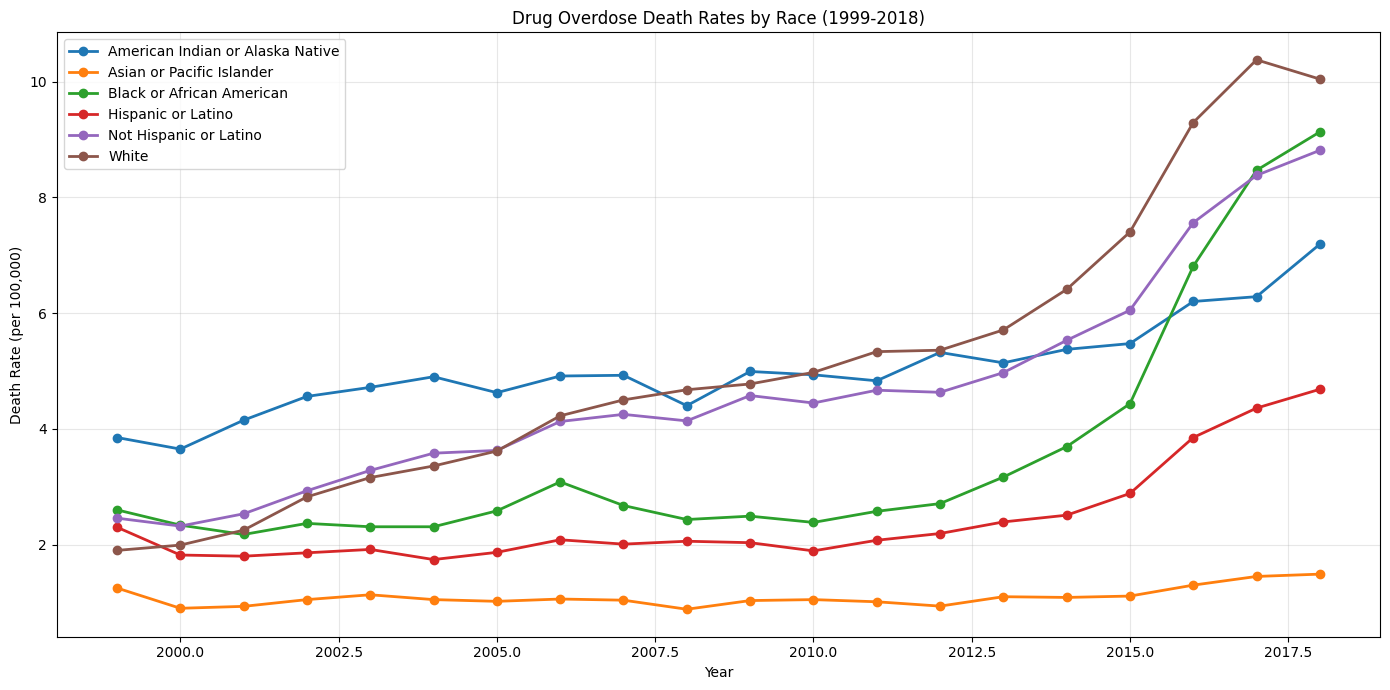

In [ ]:

q5_data = df_clean[(df_clean['Race'] != 'All') & (df_clean['Sex'] != 'All')].copy()

q5_race_data = q5_data.groupby(['Year', 'Race'])['DeathRate'].mean().reset_index()

q5_pivot = q5_race_data.pivot_table(values='DeathRate', index='Year', columns='Race')

print(q5_pivot)

print("\n\nSummary Statistics by Race:")
print(q5_pivot.describe())

plt.figure(figsize=(14, 7))
for race in q5_pivot.columns:
    plt.plot(q5_pivot.index, q5_pivot[race], marker='o', linewidth=2, label=race)

plt.xlabel('Year')
plt.ylabel('Death Rate (per 100,000)')
plt.title('Drug Overdose Death Rates by Race (1999-2018)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Question 6: Have any groups actually decreased in drug overdose cases?

 I was also curious if any groups actually had decreases in drug overdose deaths, since that could indicate things as well. The results surprised me a bit because it kind of contradicts the results from 5. It says that the groups that decreased were black men, hispanic men, native women and black women.

In [21]:
q6_data = df_clean[(df_clean['Sex'] != 'All') & (df_clean['Race'] != 'All')].copy()

q6_changes = []
for sex in q6_data['Sex'].unique():
    for race in q6_data['Race'].unique():
        subset = q6_data[(q6_data['Sex'] == sex) & (q6_data['Race'] == race)].sort_values('Year')
        
        if len(subset) > 0:
            rate_1999 = subset[subset['Year'] == 1999]['DeathRate'].values
            rate_2018 = subset[subset['Year'] == 2018]['DeathRate'].values
            
            if len(rate_1999) > 0 and len(rate_2018) > 0:
                change = rate_2018[0] - rate_1999[0]
                pct_change = (change / rate_1999[0]) * 100 if rate_1999[0] > 0 else 0
                q6_changes.append({
                    'Sex': sex,
                    'Race': race,
                    'Rate_1999': rate_1999[0],
                    'Rate_2018': rate_2018[0],
                    'Change': change,
                    'Percent_Change': pct_change
                })

q6_changes_df = pd.DataFrame(q6_changes).sort_values('Change')

print("\nQUESTION 6: Groups with Decreasing Death Rates (1999-2018)")
print("=" * 60)

decreasing = q6_changes_df[q6_changes_df['Change'] < 0]
if len(decreasing) > 0:
    print("Groups with DECREASED death rates:")
    print(decreasing.to_string(index=False))
else:
    print("No demographic groups showed a decrease in death rates.")

print("\n\nAll demographic groups sorted by change (least to most increase):")
print(q6_changes_df.to_string(index=False))

num_increase = len(q6_changes_df[q6_changes_df['Change'] > 0])
num_decrease = len(q6_changes_df[q6_changes_df['Change'] < 0])
num_no_change = len(q6_changes_df[q6_changes_df['Change'] == 0])

print(f"\n\nSummary:")
print(f"  Groups with INCREASED rates: {num_increase}")
print(f"  Groups with DECREASED rates: {num_decrease}")
print(f"  Groups with NO change: {num_no_change}")


QUESTION 6: Groups with Decreasing Death Rates (1999-2018)
Groups with DECREASED death rates:
   Sex                             Race  Rate_1999  Rate_2018  Change  Percent_Change
  Male        Black or African American       11.5        3.3    -8.2      -71.304348
  Male               Hispanic or Latino        8.6        2.1    -6.5      -75.581395
Female American Indian or Alaska Native        4.6        2.5    -2.1      -45.652174
Female        Black or African American        3.9        2.0    -1.9      -48.717949


All demographic groups sorted by change (least to most increase):
   Sex                             Race  Rate_1999  Rate_2018  Change  Percent_Change
  Male        Black or African American       11.5        3.3    -8.2      -71.304348
  Male               Hispanic or Latino        8.6        2.1    -6.5      -75.581395
Female American Indian or Alaska Native        4.6        2.5    -2.1      -45.652174
Female        Black or African American        3.9        2.0  